# Pós- graduação CESAR School - Engenharia e Análise de Dados.

# Aluno: João Henrique Ayres Pereira
# E-mail do aluno: jhap@cesar.school
# Disciplina: RRedes Neurais Artificiais e Deep Learning
# Professor: Vitor Casadei

In [2]:
# fazendo as devidas importações das bibliotecas python para regressão logística:

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
# importando e visualizando o dataset:

df = pd.read_csv('/content/student_exam_data.csv')
df.head(10)

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
5,2.403951,49.757016,0
6,1.522753,94.655631,0
7,8.795585,89.352235,1
8,6.410035,96.987995,1
9,7.372653,83.543171,1


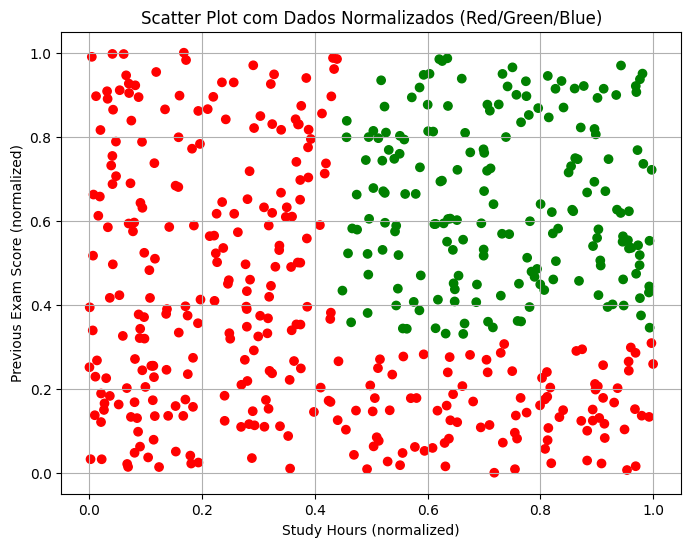

In [8]:
# Normalizando colunas numéricas
cols_to_norm = ['Study Hours', 'Previous Exam Score']
df_norm = df.copy()
df_norm[cols_to_norm] = (df_norm[cols_to_norm] - df_norm[cols_to_norm].min()) / (df_norm[cols_to_norm].max() - df_norm[cols_to_norm].min())

# Mapeando cores para as classes
color_map = {
    0: 'red',
    1: 'green',
    2: 'blue'
}

colors = df_norm['Pass/Fail'].map(color_map)

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df_norm['Study Hours'], df_norm['Previous Exam Score'], c=colors)

plt.xlabel('Study Hours (normalized)')
plt.ylabel('Previous Exam Score (normalized)')
plt.title('Scatter Plot com Dados Normalizados (Red/Green/Blue)')
plt.grid(True)
plt.show()


In [17]:
import torch

# preparação para o pytorch:

x_tensor = torch.FloatTensor(df_norm[['Study Hours', 'Previous Exam Score']].values)
y_tensor = torch.LongTensor(df_norm['Pass/Fail'].values)

In [11]:
y_tensor

tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

In [18]:
import torch.nn as nn

# construindo o modelo de rede baseado no nn.liner:

model = nn.Linear(2,3)  # 2 entradas e 3 saídas
model.state_dict()

OrderedDict([('weight',
              tensor([[-0.2739,  0.5846],
                      [-0.6371, -0.0431],
                      [ 0.2825,  0.4445]])),
             ('bias', tensor([-0.3076,  0.2018, -0.5068]))])

In [20]:
# fazendo uma previsão (predict):

out = model(x_tensor[:10,:]) # 4 amostras
out

tensor([[-0.0026, -0.0666, -0.0913],
        [-0.2575, -0.4311,  0.0011],
        [-0.3300, -0.2803, -0.1627],
        [ 0.0032, -0.2161,  0.0244],
        [ 0.0501,  0.0749, -0.1598],
        [-0.2566,  0.0976, -0.3930],
        [ 0.2101,  0.1283, -0.0868],
        [-0.0658, -0.3890,  0.1048],
        [ 0.0824, -0.2236,  0.0859],
        [-0.0789, -0.2829,  0.0164]], grad_fn=<AddmmBackward0>)

In [22]:
import torch.nn.functional as F
oo = F.softmax(out,dim=1)
oo

tensor([[0.3505, 0.3288, 0.3207],
        [0.3189, 0.2681, 0.4130],
        [0.3093, 0.3251, 0.3656],
        [0.3540, 0.2843, 0.3616],
        [0.3526, 0.3615, 0.2859],
        [0.3033, 0.4322, 0.2646],
        [0.3753, 0.3458, 0.2789],
        [0.3437, 0.2487, 0.4076],
        [0.3650, 0.2688, 0.3662],
        [0.3430, 0.2797, 0.3773]], grad_fn=<SoftmaxBackward0>)

In [23]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.3505, 0.3288, 0.3207],
        [0.3189, 0.2681, 0.4130],
        [0.3093, 0.3251, 0.3656],
        [0.3540, 0.2843, 0.3616],
        [0.3526, 0.3615, 0.2859],
        [0.3033, 0.4322, 0.2646],
        [0.3753, 0.3458, 0.2789],
        [0.3437, 0.2487, 0.4076],
        [0.3650, 0.2688, 0.3662],
        [0.3430, 0.2797, 0.3773]], grad_fn=<SoftmaxBackward0>)

In [24]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([0, 2, 2, 2, 1, 1, 0, 2, 2, 2])
tensor([0.3505, 0.4130, 0.3656, 0.3616, 0.3615, 0.4322, 0.3753, 0.4076, 0.3662,
        0.3773], grad_fn=<MaxBackward0>)


In [36]:
import torch.nn as nn
import torch.nn.functional as F
from IPython import display # Add this import for display and clear_output
# The import for Variable is no longer needed as it's deprecated
# from torch.autograd import Variable

# treinando o modelo

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath

        x_min, x_max = self.X[:, 0].min() - .5, self.X[:, 0].max() + .5
        y_min, y_max = self.X[:, 1].min() - .5, self.X[:, 1].max() + .5

        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h),
                                       np.arange(y_min, y_max, h))

        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        # FIGURA 1 - PERDA
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, self.n_epoch)
        self.ax1.set_xlabel('Época')
        self.ax1.set_ylabel('Perda')
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        # FIGURA 2 - DECISION BOUNDARY
        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(self.X[:,0].min(), self.X[:,0].max())
        self.ax2.set_ylim(self.X[:,1].min(), self.X[:,1].max())
        self.ax2.set_xlabel('Study Hours')
        self.ax2.set_ylabel('Previous Exam Score')
        self.ax2.set_title('Fronteiras de decisão')

        # FIGURA 3 - PROBABILIDADE
        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(self.X[:,0].min(), self.X[:,0].max())
        self.ax3.set_ylim(self.X[:,1].min(), self.X[:,1].max())
        self.ax3.set_xlabel('Study Hours')
        self.ax3.set_ylabel('Previous Exam Score')
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs:
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Zc = predict(self.model, torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r','g'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1],
                                 s=40, c=colors[self.Y], edgecolors='k')

                Zp = predict_prob(self.model, torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                colors = np.array(['r','g'])
                self.ax3.scatter(self.X[:, 0], self.X[:, 1],
                                 s=40, c=colors[self.Y], edgecolors='k')

                display.display(self.fig)
                display.clear_output(wait=True)


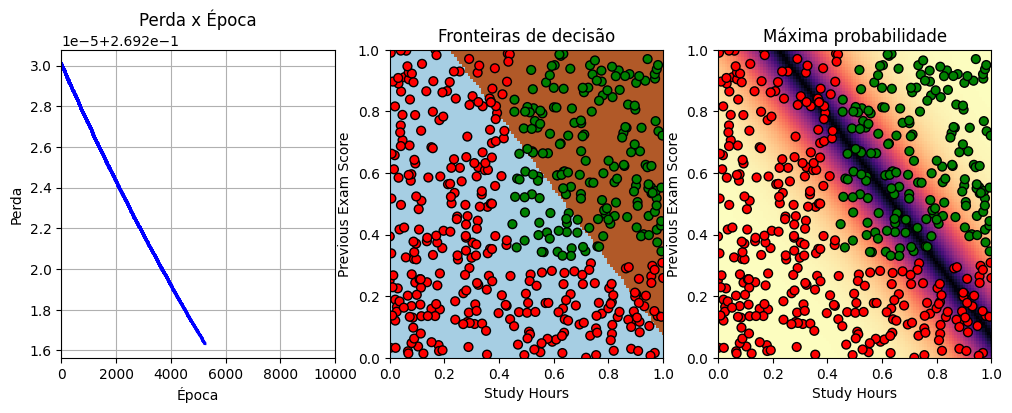

In [ ]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()


b_epoch = 10000

#Definindo o plotter
# Fix: Pass x_tensor.numpy() and y_tensor.numpy() to MyPlotter
my_plot = MyPlotter(model, x_tensor.numpy(), y_tensor.numpy(), nb_epoch)

losses = []
for i in range(nb_epoch):
    # predict da rede
    # Fix: Use x_tensor directly
    output = model(x_tensor)

    # calcula a perda
    # Fix: Use y_tensor directly
    loss = criterion(output, y_tensor)

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    my_plot.on_epoch_end(i, {'loss': loss.data.item()});
    final_loss = loss.data.item()

print('Final loss:', final_loss)